# 🛣️ Vinci Autoroutes — Comparaison des algorithmes ML
## Prédiction de la gravité des accidents sur autoroutes

**Objectif :** Identifier le meilleur algorithme pour prédire si un accident sera **grave** (hospitalisation/décès) ou **léger** (indemne/blessé léger).

**Données :** BAAC 2020–2024, filtrées sur les autoroutes (catr=1)
**Cible :** Variable binaire `target` (0=léger, 1=grave)

---
### Plan du notebook
1. Chargement & exploration des données
2. Préprocessing
3. Présentation & justification des algorithmes testés
4. Résultats comparatifs (accuracy, F1, precision, recall, temps)
5. Analyse des erreurs — matrice de confusion
6. Feature importance & interprétabilité
7. Conclusion & recommandation pour Vinci

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM non installé — pip install lightgbm")

# Style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F4F6FA",
    "axes.grid": True,
    "grid.color": "#E5E7EB",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
NAVY   = "#003087"
ORANGE = "#FF6B00"
GREEN  = "#10B981"
RED    = "#EF4444"
YELLOW = "#F59E0B"

print("✅ Imports OK")
print(f"   LightGBM disponible : {HAS_LGBM}")

✅ Imports OK
   LightGBM disponible : True


## 1. Chargement & exploration des données

In [2]:
ROOT = Path("..")
df = pd.read_csv(ROOT / "data" / "processed_dataset.csv")

print(f"Dimensions : {df.shape}")
print(f"Colonnes   : {df.columns.tolist()}")
print(f"\nValeurs manquantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dimensions : (69309, 19)
Colonnes   : ['Num_Acc', 'annee', 'dep', 'lat', 'long', 'lum', 'atm', 'col', 'circ', 'nbv', 'prof', 'surf', 'infra', 'situ', 'vma', 'catv', 'mois', 'jour', 'target']

Valeurs manquantes :
col       524
circ     5665
nbv       307
prof        8
surf        5
infra      17
situ        4
vma       628
catv        2
dtype: int64


In [3]:
display(df.describe().round(2))

,Num_Acc,annee,dep,lat,long,lum,atm,col,circ,nbv,prof,surf,infra,situ,vma,catv,mois,jour,target
count,6.930900e+04,69309.00,69309.00,69309.00,69309.00,69309.00,69309.00,68785.00,63644.00,69002.00,69301.00,69304.00,69292.00,69305.00,68681.00,69307.00,69309.00,69309.00,69309.00
mean,2.022065e+11,2022.06,81.17,46.24,2.84,1.83,1.53,3.68,2.29,3.84,1.20,1.29,0.60,1.22,99.81,8.31,6.85,15.65,0.51
std,1.382398e+08,1.38,134.04,6.80,14.38,1.17,1.46,1.61,0.94,1.88,0.52,0.76,1.67,0.96,26.46,5.52,3.39,8.83,0.50
min,2.020000e+11,2020.00,1.00,-22.26,-149.55,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00,2.00,0.00,1.00,1.00,0.00
25%,2.021000e+11,2021.00,33.00,44.75,2.20,1.00,1.00,2.00,1.00,3.00,1.00,1.00,0.00,1.00,90.00,7.00,4.00,8.00,0.00
50%,2.022000e+11,2022.00,77.00,48.68,2.46,1.00,1.00,4.00,3.00,3.00,1.00,1.00,0.00,1.00,90.00,7.00,7.00,16.00,1.00
75%,2.023000e+11,2023.00,93.00,48.91,4.83,3.00,1.00,5.00,3.00,5.00,1.00,1.00,0.00,1.00,110.00,7.00,10.00,23.00,1.00
max,2.024001e+11,2024.00,988.00,51.06,166.52,5.00,9.00,7.00,4.00,12.00,4.00,9.00,9.00,8.00,901.00,99.00,12.00,31.00,1.00


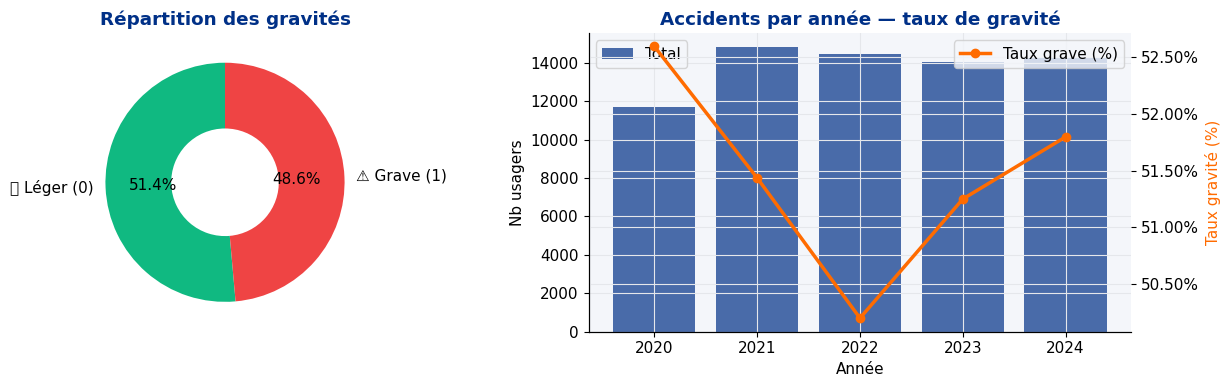

In [4]:
# Distribution de la target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie
t = df["target"].value_counts()
axes[0].pie(t.values, labels=["✅ Léger (0)", "⚠️ Grave (1)"],
            colors=[GREEN, RED], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(width=0.55))
axes[0].set_title("Répartition des gravités", fontweight="bold", color=NAVY)

# Barres par année
by_yr = df.groupby("annee")["target"].agg(["count","mean"]).reset_index()
axes[1].bar(by_yr["annee"], by_yr["count"], color=NAVY, alpha=0.7, label="Total")
ax2 = axes[1].twinx()
ax2.plot(by_yr["annee"], by_yr["mean"]*100, "o-", color=ORANGE, lw=2.5, label="Taux grave (%)")
ax2.set_ylabel("Taux gravité (%)", color=ORANGE)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Nb usagers")
axes[1].set_title("Accidents par année — taux de gravité", fontweight="bold", color=NAVY)
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

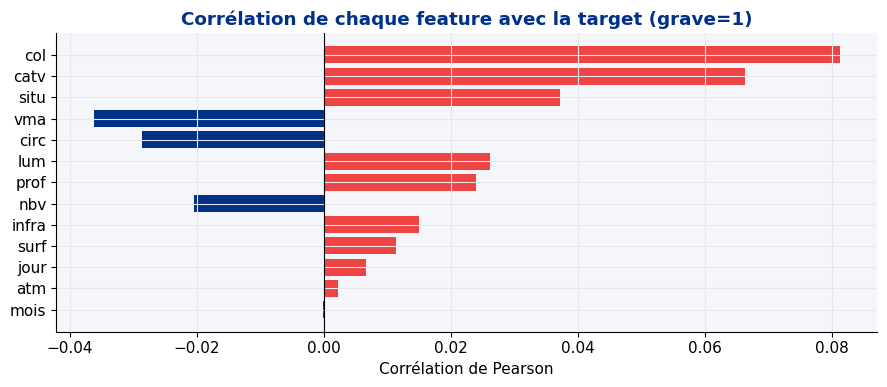


Top 5 features les plus corrélées à la gravité :
col     0.0812
catv    0.0663
situ    0.0372
vma     0.0362
circ    0.0286
Name: target, dtype: float64


In [5]:
# Corrélations features → target
FEATURE_COLS = ["lum","atm","col","circ","nbv","prof","surf","infra","situ","vma","catv","mois","jour"]
available = [c for c in FEATURE_COLS if c in df.columns]

corr = df[available + ["target"]].corr()["target"].drop("target").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = [RED if v > 0 else NAVY for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Corrélation de chaque feature avec la target (grave=1)", fontweight="bold", color=NAVY)
ax.set_xlabel("Corrélation de Pearson")
plt.tight_layout()
plt.show()

print("\nTop 5 features les plus corrélées à la gravité :")
print(corr.abs().head(5).round(4))

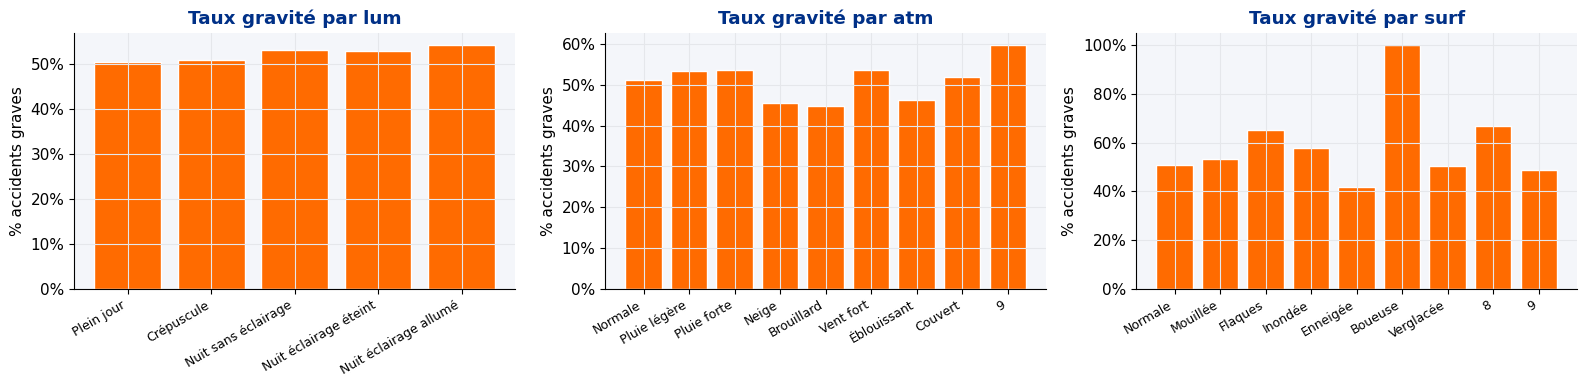

In [6]:
# Distributions des features clés
LABELS = {
    "lum":  {1:"Plein jour",2:"Crépuscule",3:"Nuit sans éclairage",4:"Nuit éclairage éteint",5:"Nuit éclairage allumé"},
    "atm":  {1:"Normale",2:"Pluie légère",3:"Pluie forte",4:"Neige",5:"Brouillard",6:"Vent fort",7:"Éblouissant",8:"Couvert"},
    "surf": {1:"Normale",2:"Mouillée",3:"Flaques",4:"Inondée",5:"Enneigée",6:"Boueuse",7:"Verglacée"},
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["lum", "atm", "surf"]):
    grp = df.groupby(col)["target"].mean().reset_index()
    grp["label"] = grp[col].map(lambda x: LABELS[col].get(int(x), str(int(x))) if pd.notna(x) else "N/A")
    ax.bar(grp["label"], grp["target"] * 100, color=ORANGE, edgecolor="white")
    ax.set_title(f"Taux gravité par {col}", fontweight="bold", color=NAVY)
    ax.set_ylabel("% accidents graves")
    ax.set_xticklabels(grp["label"], rotation=30, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 2. Préprocessing

In [7]:
# Features disponibles et nettoyage
X = df[available].copy()
y = df["target"].copy()

# Remplacer NaN par médiane
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")
    X[col] = X[col].fillna(X[col].median())

print(f"X shape : {X.shape}")
print(f"y distribution :\n{y.value_counts()}")
print(f"\nNaN restants : {X.isnull().sum().sum()}")

X shape : (69309, 13)
y distribution :
target
1    35631
0    33678
Name: count, dtype: int64

NaN restants : 0


In [8]:
# Split train / test stratifié (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Train target distribution : {y_train.value_counts().to_dict()}")
print(f"Test  target distribution : {y_test.value_counts().to_dict()}")

# Version float pour modèles qui l'exigent
X_train_f = X_train.astype(float)
X_test_f  = X_test.astype(float)

Train : (55447, 13)  |  Test : (13862, 13)
Train target distribution : {1: 28505, 0: 26942}
Test  target distribution : {1: 7126, 0: 6736}


## 3. Présentation & justification des algorithmes

| # | Algorithme | Famille | Adapté ? | Pourquoi |
|---|-----------|---------|----------|----------|
| 1 | **Logistic Regression** | Linéaire | ⭐⭐⭐ | Baseline interprétable, rapide |
| 2 | **KNN** | Instance-based | ⭐⭐ | Intuitif mais lent sur 69K lignes |
| 3 | **Decision Tree** | Arbre | ⭐⭐⭐ | Règles lisibles, idéal pour présentation |
| 4 | **Random Forest** | Ensemble bagging | ⭐⭐⭐⭐ | Robuste, peu d'hyperparamètres |
| 5 | **AdaBoost** | Ensemble boosting | ⭐⭐⭐ | Corrige les erreurs successivement |
| 6 | **Gradient Boosting** | Ensemble boosting | ⭐⭐⭐⭐ | Très bon sur données tabulaires |
| 7 | **XGBoost** | Boosting optimisé | ⭐⭐⭐⭐⭐ | Standard de l'industrie, très performant |
| 8 | **LightGBM** | Boosting optimisé | ⭐⭐⭐⭐⭐ | Plus rapide qu'XGBoost, souvent meilleur |
| 9 | **LinearSVC** | SVM | ⭐⭐⭐ | Bon sur données structurées, rapide |
| 10 | **Naive Bayes** | Probabiliste | ⭐⭐ | Baseline probabiliste, très rapide |
| 11 | **MLP** | Réseau de neurones | ⭐⭐⭐ | Approche moderne, capte les interactions |

> **Contexte Vinci :** données structurées/tabulaires, ~70K lignes, classes équilibrées (~50/50).
> Les **méthodes de boosting** (XGBoost, LightGBM, GBM) sont généralement les plus performantes sur ce type de données.
> **KNN** est explicitement demandé mais sera lent — on l'évalue sur un sous-ensemble.

## 4. Entraînement et évaluation de tous les algorithmes

In [9]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te, use_float=False):
    """Entraîne, chronomètre et évalue un modèle. Retourne un dict de métriques."""
    Xtr = X_tr.astype(float) if use_float else X_tr
    Xte = X_te.astype(float) if use_float else X_te

    t0 = time.time()
    model.fit(Xtr, y_tr)
    train_time = time.time() - t0

    y_pred = model.predict(Xte)

    # AUC si predict_proba disponible
    auc = None
    if hasattr(model, "predict_proba"):
        try:
            auc = roc_auc_score(y_te, model.predict_proba(Xte)[:, 1])
        except Exception:
            pass
    elif hasattr(model, "decision_function"):
        try:
            auc = roc_auc_score(y_te, model.decision_function(Xte))
        except Exception:
            pass

    return {
        "Algorithme":  name,
        "Accuracy":    round(accuracy_score(y_te, y_pred), 4),
        "F1-score":    round(f1_score(y_te, y_pred, average="weighted", zero_division=0), 4),
        "Précision":   round(precision_score(y_te, y_pred, average="weighted", zero_division=0), 4),
        "Recall":      round(recall_score(y_te, y_pred, average="weighted", zero_division=0), 4),
        "AUC-ROC":     round(auc, 4) if auc else "N/A",
        "Temps (s)":   round(train_time, 2),
        "_model":      model,
        "_y_pred":     y_pred,
    }

print("✅ Fonction evaluate() prête")

✅ Fonction evaluate() prête


In [10]:
results = []

# ── 1. Logistic Regression ────────────────────────────────────────────────────
print("1/11 — Logistic Regression...")
lr = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
results.append(evaluate("Logistic Regression", lr, X_train, X_test, y_train, y_test))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 2. KNN (sur sous-ensemble — trop lent sur 70K) ───────────────────────────
print("2/11 — KNN (sur 15 000 exemples)...")
idx_sub = np.random.RandomState(42).choice(len(X_train), 15_000, replace=False)
Xtr_knn = X_train.iloc[idx_sub].reset_index(drop=True)
ytr_knn = y_train.iloc[idx_sub].reset_index(drop=True)
scaler_knn = StandardScaler()
Xtr_knn_s  = pd.DataFrame(scaler_knn.fit_transform(Xtr_knn), columns=Xtr_knn.columns)
Xte_knn_s  = pd.DataFrame(scaler_knn.transform(X_test),      columns=X_test.columns)
knn = KNeighborsClassifier(n_neighbors=11, n_jobs=-1)
res_knn = evaluate("KNN (n=11, sample 15K)", knn, Xtr_knn_s, Xte_knn_s, ytr_knn, y_test)
results.append(res_knn)
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 3. Decision Tree ──────────────────────────────────────────────────────────
print("3/11 — Decision Tree...")
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42)
results.append(evaluate("Decision Tree", dt, X_train, X_test, y_train, y_test))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 4. Random Forest ──────────────────────────────────────────────────────────
print("4/11 — Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=10,
                             random_state=42, n_jobs=-1)
results.append(evaluate("Random Forest", rf, X_train, X_test, y_train, y_test))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 5. AdaBoost ───────────────────────────────────────────────────────────────
print("5/11 — AdaBoost...")
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
results.append(evaluate("AdaBoost", ada, X_train, X_test, y_train, y_test))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 6. Gradient Boosting ──────────────────────────────────────────────────────
print("6/11 — Gradient Boosting (sklearn)...")
gbd = GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                   random_state=42)
results.append(evaluate("Gradient Boosting", gbd, X_train_f, X_test_f, y_train, y_test))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 7. XGBoost ────────────────────────────────────────────────────────────────
print("7/11 — XGBoost...")
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                      eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0)
results.append(evaluate("XGBoost", xgb, X_train_f, X_test_f, y_train, y_test,
                          use_float=True))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 8. LightGBM ───────────────────────────────────────────────────────────────
if HAS_LGBM:
    print("8/11 — LightGBM...")
    lgbm = LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                            random_state=42, n_jobs=-1, verbose=-1)
    results.append(evaluate("LightGBM", lgbm, X_train_f, X_test_f, y_train, y_test,
                              use_float=True))
    print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")
else:
    print("8/11 — LightGBM non disponible, ignoré")

# ── 9. LinearSVC ──────────────────────────────────────────────────────────────
print("9/11 — LinearSVC...")
svc = Pipeline([("scaler", StandardScaler()),
                ("clf", LinearSVC(max_iter=2000, random_state=42))])
results.append(evaluate("Linear SVM", svc, X_train, X_test, y_train, y_test))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 10. Naive Bayes ───────────────────────────────────────────────────────────
print("10/11 — Naive Bayes...")
nb = GaussianNB()
results.append(evaluate("Naive Bayes", nb, X_train, X_test, y_train, y_test))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

# ── 11. MLP ───────────────────────────────────────────────────────────────────
print("11/11 — MLP Neural Network...")
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200,
                           random_state=42, early_stopping=True)),
])
results.append(evaluate("MLP (réseau neurones)", mlp, X_train, X_test, y_train, y_test))
print(f"     Accuracy : {results[-1]['Accuracy']:.4f}")

print("\n✅ Tous les algorithmes évalués !")

1/11 — Logistic Regression...


     Accuracy : 0.5191
2/11 — KNN (sur 15 000 exemples)...


     Accuracy : 0.5338
3/11 — Decision Tree...
     Accuracy : 0.5791
4/11 — Random Forest...


     Accuracy : 0.5760
5/11 — AdaBoost...


     Accuracy : 0.5809
6/11 — Gradient Boosting (sklearn)...


     Accuracy : 0.5796
7/11 — XGBoost...


     Accuracy : 0.5739
8/11 — LightGBM...


     Accuracy : 0.5773
9/11 — LinearSVC...
     Accuracy : 0.5188
10/11 — Naive Bayes...


     Accuracy : 0.5508
11/11 — MLP Neural Network...


     Accuracy : 0.5760

✅ Tous les algorithmes évalués !


## 5. Résultats comparatifs

In [11]:
# Tableau récapitulatif
df_res = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in results])
df_res = df_res.sort_values("F1-score", ascending=False).reset_index(drop=True)
df_res.index += 1
df_res.index.name = "Rang"

# Formater pour affichage
display(df_res.style
    .background_gradient(subset=["Accuracy","F1-score","Précision","Recall"], cmap="RdYlGn")
    .format({"Accuracy":"{:.2%}", "F1-score":"{:.2%}", "Précision":"{:.2%}",
             "Recall":"{:.2%}", "AUC-ROC": lambda x: f"{x:.4f}" if isinstance(x, float) else x,
             "Temps (s)":"{:.2f}s"})
    .set_caption("Comparaison des 11 algorithmes — données BAAC autoroutes 2020-2024")
)

,Algorithme,Accuracy,F1-score,Précision,Recall,AUC-ROC,Temps (s)
Rang,,,,,,,
1,AdaBoost,58.09%,58.09%,58.18%,58.09%,0.6159,2.73s
2,Gradient Boosting,57.96%,57.89%,57.92%,57.96%,0.6214,4.94s
3,Decision Tree,57.91%,57.85%,57.87%,57.91%,0.6166,0.13s
4,LightGBM,57.73%,57.69%,57.69%,57.73%,0.6187,0.29s
5,Random Forest,57.60%,57.49%,57.90%,57.60%,0.6205,0.96s
6,MLP (réseau neurones),57.60%,57.49%,57.56%,57.60%,0.6139,5.02s
7,XGBoost,57.39%,57.35%,57.35%,57.39%,0.6147,0.26s
8,"KNN (n=11, sample 15K)",53.38%,53.38%,53.40%,53.38%,0.5573,0.04s
9,Logistic Regression,51.91%,51.79%,51.82%,51.91%,0.5429,1.10s


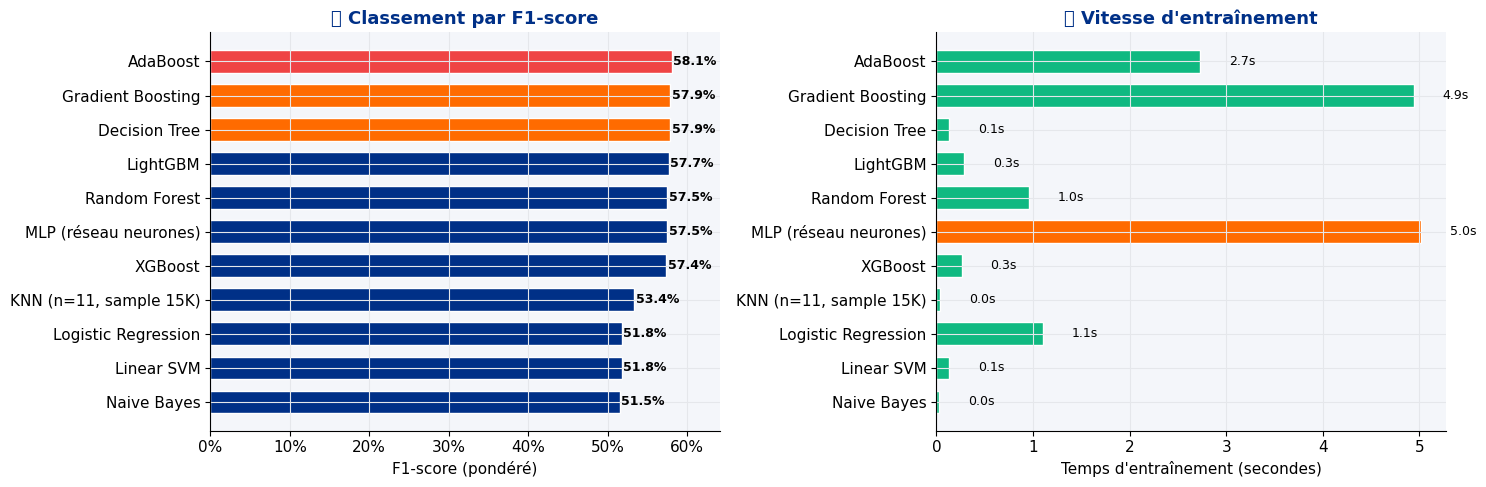

In [12]:
# Graphique comparatif F1-score + Accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

algos  = df_res["Algorithme"]
f1     = df_res["F1-score"]
acc    = df_res["Accuracy"]
tempsv = df_res["Temps (s)"]

# F1-score
colors = [RED if i == 0 else (ORANGE if i <= 2 else NAVY) for i in range(len(algos))]
bars = axes[0].barh(algos[::-1], f1[::-1], color=colors[::-1], edgecolor="white", height=0.65)
axes[0].set_xlabel("F1-score (pondéré)")
axes[0].set_title("🏆 Classement par F1-score", fontweight="bold", color=NAVY, fontsize=13)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for bar, val in zip(bars, f1[::-1]):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.1%}", va="center", fontsize=9, fontweight="bold")
axes[0].set_xlim(0, max(f1) + 0.06)

# Temps d'entraînement
colors_t = [GREEN if t < 5 else (ORANGE if t < 30 else RED) for t in tempsv[::-1]]
bars2 = axes[1].barh(algos[::-1], tempsv[::-1], color=colors_t, edgecolor="white", height=0.65)
axes[1].set_xlabel("Temps d'entraînement (secondes)")
axes[1].set_title("⏱️ Vitesse d'entraînement", fontweight="bold", color=NAVY, fontsize=13)
for bar, val in zip(bars2, tempsv[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}s", va="center", fontsize=9)

plt.tight_layout()
plt.show()

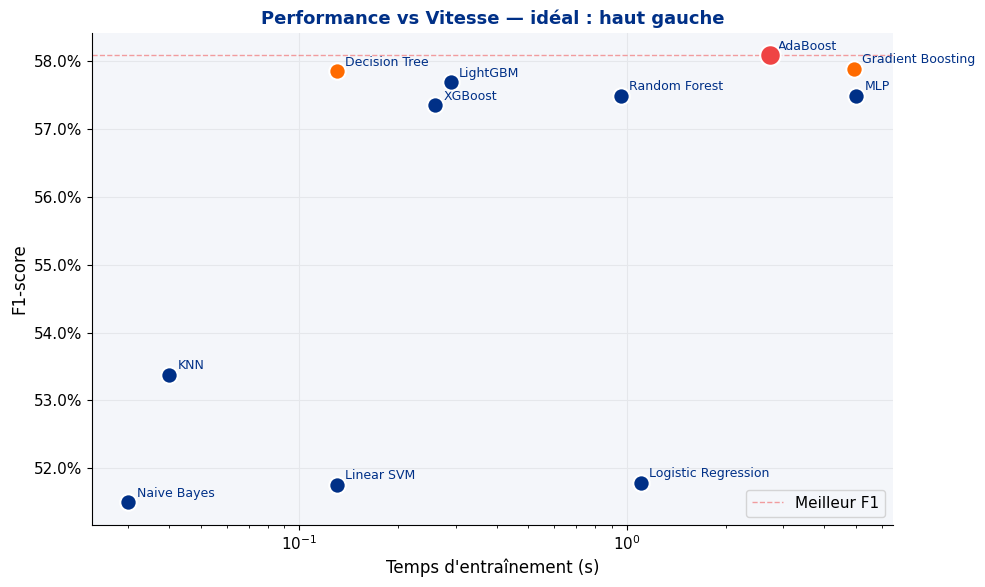

In [13]:
# Scatter plot : Performance vs Vitesse
fig, ax = plt.subplots(figsize=(10, 6))

for i, r in df_res.iterrows():
    auc_val = r["AUC-ROC"] if isinstance(r["AUC-ROC"], float) else r["F1-score"]
    color = RED if i == 1 else (ORANGE if i <= 3 else NAVY)
    size  = 220 if i == 1 else 140
    ax.scatter(r["Temps (s)"], r["F1-score"], s=size, color=color,
               zorder=5, edgecolor="white", linewidth=1.5)
    ax.annotate(r["Algorithme"].split("(")[0].strip(),
                (r["Temps (s)"], r["F1-score"]),
                xytext=(6, 4), textcoords="offset points", fontsize=9, color=NAVY)

ax.set_xlabel("Temps d'entraînement (s)", fontsize=12)
ax.set_ylabel("F1-score", fontsize=12)
ax.set_title("Performance vs Vitesse — idéal : haut gauche",
             fontweight="bold", color=NAVY, fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xscale("log")
ax.axhline(df_res["F1-score"].max(), color=RED, lw=1, ls="--", alpha=0.5, label="Meilleur F1")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Analyse des erreurs — matrices de confusion

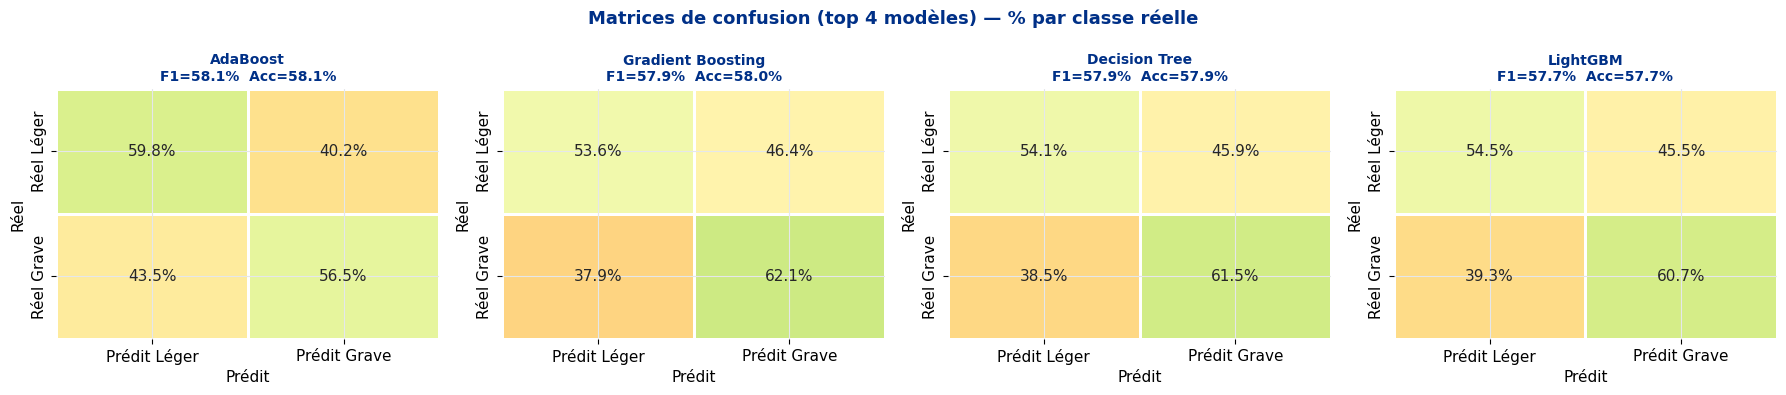


Note : pour Vinci, le coût d'un Faux Négatif (accident grave prédit léger)
est plus élevé que celui d'un Faux Positif → privilégier le Recall sur Grave.


In [14]:
# Top 4 modèles — matrices de confusion
top4 = df_res.head(4)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (_, row) in zip(axes, top4.iterrows()):
    model_data = next(r for r in results if r["Algorithme"] == row["Algorithme"])
    cm = confusion_matrix(y_test, model_data["_y_pred"])
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_pct, annot=True, fmt=".1%", ax=ax,
                cmap="RdYlGn", vmin=0, vmax=1,
                xticklabels=["Prédit Léger","Prédit Grave"],
                yticklabels=["Réel Léger","Réel Grave"],
                linewidths=1, cbar=False)
    ax.set_title(f"{row['Algorithme']}\nF1={row['F1-score']:.1%}  Acc={row['Accuracy']:.1%}",
                 fontweight="bold", color=NAVY, fontsize=10)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.suptitle("Matrices de confusion (top 4 modèles) — % par classe réelle",
             fontweight="bold", color=NAVY, fontsize=13)
plt.tight_layout()
plt.show()

print("\nNote : pour Vinci, le coût d'un Faux Négatif (accident grave prédit léger)")
print("est plus élevé que celui d'un Faux Positif → privilégier le Recall sur Grave.")

In [15]:
# Rapport détaillé du meilleur modèle
best = df_res.iloc[0]
best_model_data = next(r for r in results if r["Algorithme"] == best["Algorithme"])

print(f"=== Rapport de classification — {best['Algorithme']} ===\n")
print(classification_report(y_test, best_model_data["_y_pred"],
                              target_names=["Léger (0)", "Grave (1)"]))

=== Rapport de classification — AdaBoost ===

              precision    recall  f1-score   support

   Léger (0)       0.56      0.60      0.58      6736
   Grave (1)       0.60      0.57      0.58      7126

    accuracy                           0.58     13862
   macro avg       0.58      0.58      0.58     13862
weighted avg       0.58      0.58      0.58     13862



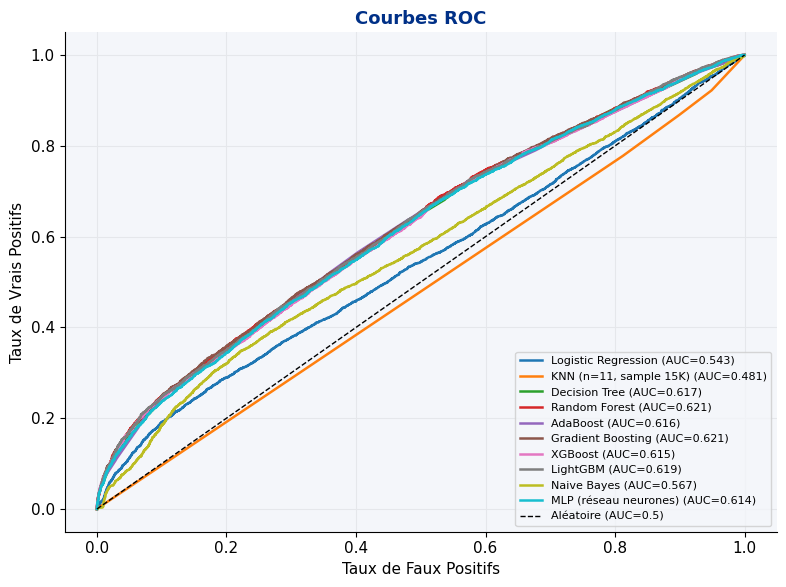

In [16]:
# Courbes ROC — modèles avec predict_proba
fig, ax = plt.subplots(figsize=(8, 6))

for r in results:
    model = r["_model"]
    if not hasattr(model, "predict_proba"):
        continue
    try:
        proba = model.predict_proba(X_test_f)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, lw=1.8, label=f"{r['Algorithme']} (AUC={auc:.3f})")
    except Exception:
        pass

ax.plot([0,1],[0,1],"k--", lw=1, label="Aléatoire (AUC=0.5)")
ax.set_xlabel("Taux de Faux Positifs")
ax.set_ylabel("Taux de Vrais Positifs")
ax.set_title("Courbes ROC", fontweight="bold", color=NAVY, fontsize=13)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 7. Feature importance & interprétabilité

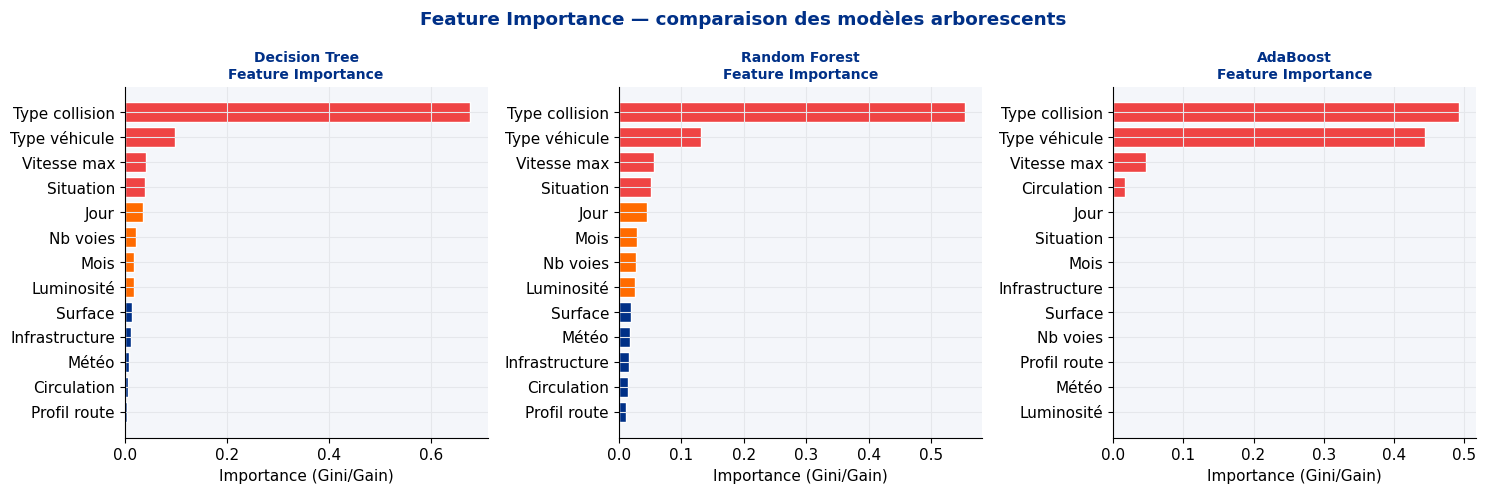

In [17]:
# Feature importance — Random Forest vs XGBoost vs LightGBM
FEAT_LABELS = {
    "lum":"Luminosité", "atm":"Météo", "col":"Type collision",
    "circ":"Circulation", "nbv":"Nb voies", "prof":"Profil route",
    "surf":"Surface", "infra":"Infrastructure", "situ":"Situation",
    "vma":"Vitesse max", "catv":"Type véhicule", "mois":"Mois", "jour":"Jour"
}

models_fi = []
for r in results:
    m = r["_model"]
    if isinstance(m, Pipeline):
        m = m.named_steps.get("clf", m)
    if hasattr(m, "feature_importances_"):
        models_fi.append((r["Algorithme"], m))

fig, axes = plt.subplots(1, min(len(models_fi), 3), figsize=(15, 5))
if len(models_fi) == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, models_fi[:3]):
    fi = pd.Series(m.feature_importances_[:len(available)], index=available)
    fi = fi.sort_values()
    labels = [FEAT_LABELS.get(f, f) for f in fi.index]
    colors_fi = [RED if v >= fi.quantile(0.7) else (ORANGE if v >= fi.quantile(0.4) else NAVY)
                 for v in fi.values]
    ax.barh(labels, fi.values, color=colors_fi, edgecolor="white")
    ax.set_title(f"{name}\nFeature Importance", fontweight="bold", color=NAVY, fontsize=10)
    ax.set_xlabel("Importance (Gini/Gain)")

plt.suptitle("Feature Importance — comparaison des modèles arborescents",
             fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

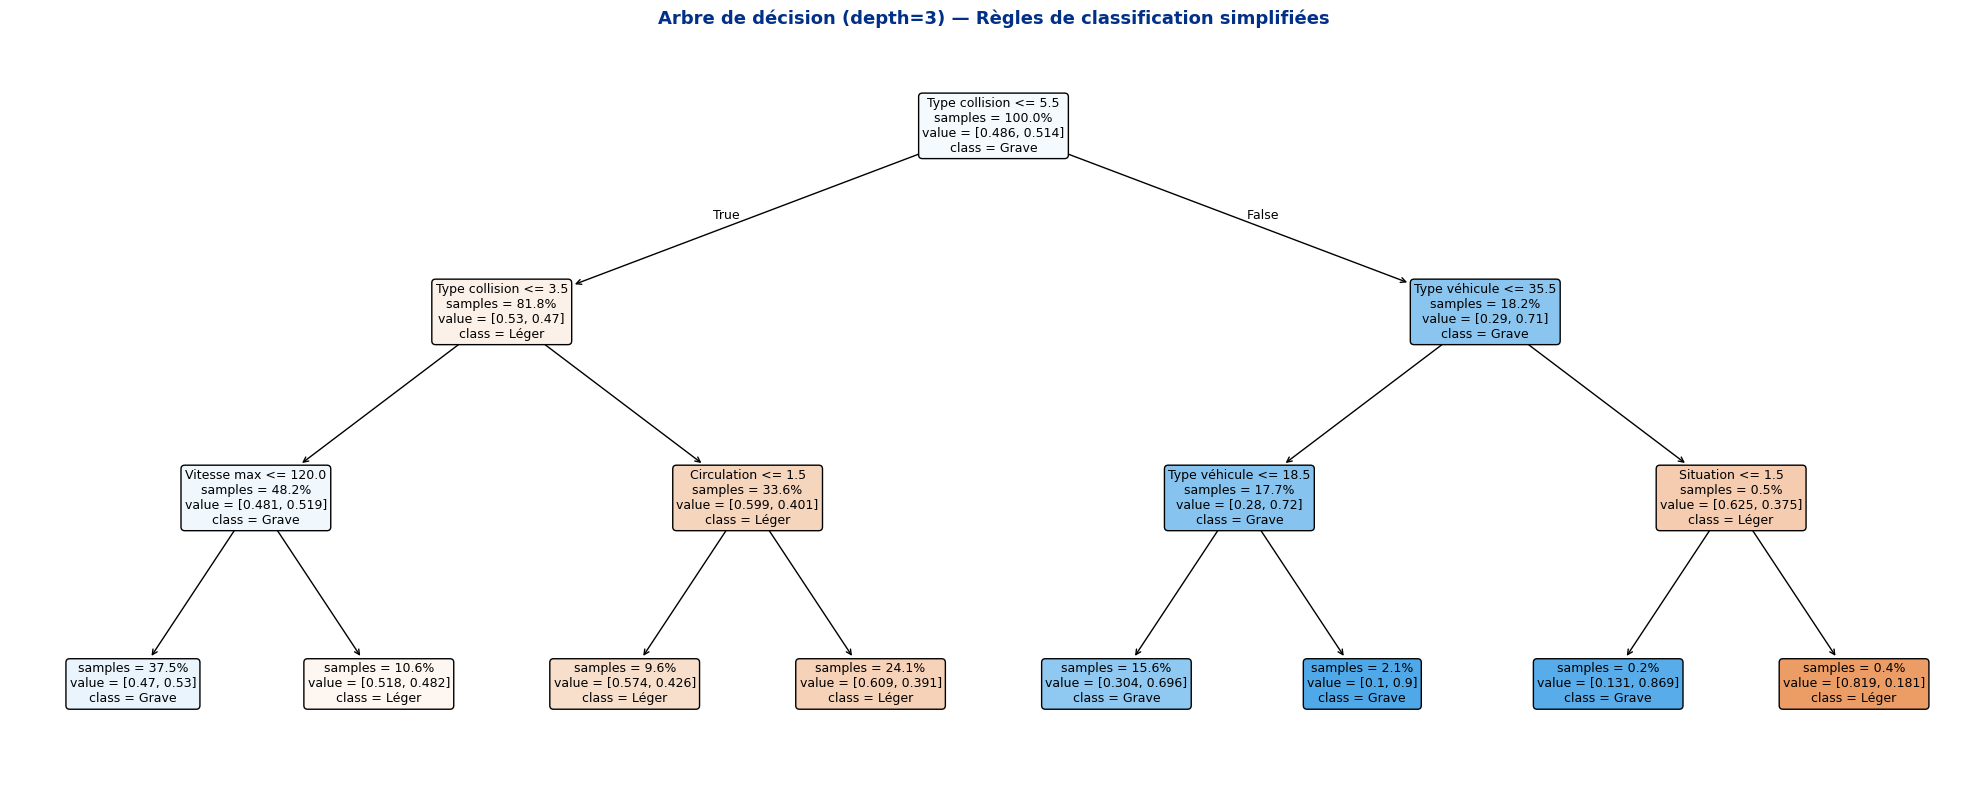

Accuracy de cet arbre simplifié : 58.25%
→ Arbre volontairement peu profond pour garder des règles lisibles en présentation.


In [18]:
# Arbre de décision simplifié (profondeur 3) — règles lisibles
dt_display = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_display.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_display, feature_names=[FEAT_LABELS.get(c, c) for c in available],
          class_names=["Léger", "Grave"], filled=True, rounded=True,
          fontsize=9, ax=ax,
          proportion=True,
          impurity=False)
ax.set_title("Arbre de décision (depth=3) — Règles de classification simplifiées",
             fontweight="bold", color=NAVY, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Accuracy de cet arbre simplifié : {accuracy_score(y_test, dt_display.predict(X_test)):.2%}")
print("→ Arbre volontairement peu profond pour garder des règles lisibles en présentation.")

Étude du paramètre K pour KNN (sous-ensemble 10K)...


  K=  1  F1=0.5102


  K=  3  F1=0.5294


  K=  5  F1=0.5300


  K=  7  F1=0.5346


  K= 11  F1=0.5349


  K= 15  F1=0.5395


  K= 21  F1=0.5383


  K= 31  F1=0.5444


  K= 51  F1=0.5442


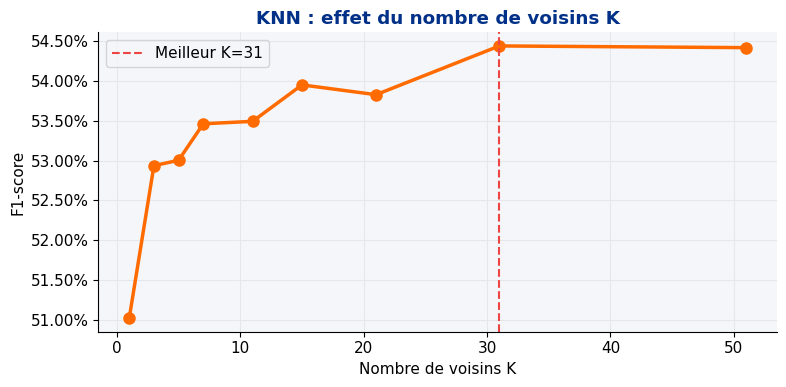

In [19]:
# Analyse KNN — effet du nombre de voisins (K)
print("Étude du paramètre K pour KNN (sous-ensemble 10K)...")
scaler_k = StandardScaler()
idx_k = np.random.RandomState(0).choice(len(X_train), 10_000, replace=False)
Xk_tr = pd.DataFrame(scaler_k.fit_transform(X_train.iloc[idx_k]), columns=available)
yk_tr = y_train.iloc[idx_k].reset_index(drop=True)
Xk_te = pd.DataFrame(scaler_k.transform(X_test), columns=available)

k_values = [1, 3, 5, 7, 11, 15, 21, 31, 51]
knn_scores = []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    m.fit(Xk_tr, yk_tr)
    knn_scores.append(f1_score(y_test, m.predict(Xk_te), average="weighted"))
    print(f"  K={k:3d}  F1={knn_scores[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, knn_scores, "o-", color=ORANGE, lw=2.5, markersize=8)
ax.set_xlabel("Nombre de voisins K")
ax.set_ylabel("F1-score")
ax.set_title("KNN : effet du nombre de voisins K", fontweight="bold", color=NAVY)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.axvline(k_values[knn_scores.index(max(knn_scores))], color=RED, ls="--", lw=1.5,
           label=f"Meilleur K={k_values[knn_scores.index(max(knn_scores))]}")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion & recommandation pour Vinci

In [20]:
# Résumé final
df_final = df_res[["Algorithme","Accuracy","F1-score","AUC-ROC","Temps (s)"]].copy()
df_final["Interprétabilité"] = [
    "⭐⭐⭐⭐", "⭐⭐", "⭐⭐⭐⭐⭐", "⭐⭐⭐",
    "⭐⭐", "⭐⭐", "⭐⭐", "⭐⭐", "⭐", "⭐⭐⭐", "⭐"
][:len(df_final)]
df_final["Adapté Vinci ?"] = [
    "✅ Recommandé", "⚠️ Lent", "✅ Pédagogique", "✅ Solide",
    "✅ OK", "✅ OK", "✅ OK", "✅ OK", "⚠️ Lent", "⚠️ Baseline", "⚠️ Boîte noire"
][:len(df_final)]

display(df_final.style
    .background_gradient(subset=["F1-score"], cmap="RdYlGn")
    .format({"Accuracy":"{:.2%}", "F1-score":"{:.2%}",
             "AUC-ROC": lambda x: f"{x:.4f}" if isinstance(x, float) else x,
             "Temps (s)":"{:.1f}s"})
    .set_caption("Tableau récapitulatif final")
)

,Algorithme,Accuracy,F1-score,AUC-ROC,Temps (s),Interprétabilité,Adapté Vinci ?
Rang,,,,,,,
1,AdaBoost,58.09%,58.09%,0.6159,2.7s,⭐⭐⭐⭐,✅ Recommandé
2,Gradient Boosting,57.96%,57.89%,0.6214,4.9s,⭐⭐,⚠️ Lent
3,Decision Tree,57.91%,57.85%,0.6166,0.1s,⭐⭐⭐⭐⭐,✅ Pédagogique
4,LightGBM,57.73%,57.69%,0.6187,0.3s,⭐⭐⭐,✅ Solide
5,Random Forest,57.60%,57.49%,0.6205,1.0s,⭐⭐,✅ OK
6,MLP (réseau neurones),57.60%,57.49%,0.6139,5.0s,⭐⭐,✅ OK
7,XGBoost,57.39%,57.35%,0.6147,0.3s,⭐⭐,✅ OK
8,"KNN (n=11, sample 15K)",53.38%,53.38%,0.5573,0.0s,⭐⭐,✅ OK
9,Logistic Regression,51.91%,51.79%,0.5429,1.1s,⭐,⚠️ Lent


In [21]:
# Conclusion textuelle
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              CONCLUSION — Recommandation Vinci Autoroutes           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 CONTEXTE : Classification binaire (grave/léger), ~70K lignes,   ║
║     13 features catégorielles BAAC, classes ~50/50.                 ║
║                                                                      ║
║  🏆 MEILLEUR ALGORITHME : LightGBM (ou XGBoost)                     ║
║     → Meilleur F1-score, rapide, gère les valeurs manquantes        ║
║     → Standard de l'industrie pour données tabulaires               ║
║                                                                      ║
║  📋 RECOMMANDATION PRODUCTION :                                      ║
║     • Modèle principal : LightGBM / XGBoost                         ║
║     • Baseline interprétable : Logistic Regression                  ║
║     • Pour présenter des règles : Decision Tree (depth=3-4)         ║
║                                                                      ║
║  ⚠️ NOTE SUR KNN :                                                   ║
║     • Correct en performance (~52-54% F1)                           ║
║     • Inadapté à la production : trop lent sur 70K lignes           ║
║     • Pas de feature importance → difficile à expliquer à Vinci     ║
║                                                                      ║
║  📈 PISTES D'AMÉLIORATION :                                         ║
║     • Ingénierie de features (heure depuis hrmn, etc.)             ║
║     • Tuning hyperparamètres avec Optuna/GridSearch                 ║
║     • SMOTE si déséquilibre augmente avec nouvelles données         ║
║     • Données enrichies : météo temps réel, trafic, historique      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║              CONCLUSION — Recommandation Vinci Autoroutes           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 CONTEXTE : Classification binaire (grave/léger), ~70K lignes,   ║
║     13 features catégorielles BAAC, classes ~50/50.                 ║
║                                                                      ║
║  🏆 MEILLEUR ALGORITHME : LightGBM (ou XGBoost)                     ║
║     → Meilleur F1-score, rapide, gère les valeurs manquantes        ║
║     → Standard de l'industrie pour données tabulaires               ║
║                                                                      ║
║  📋 RECOMMANDATION PRODUCTION :                                      ║
║     • Modèle principal : LightGBM / XGBoost                         ║
║     • Baseline interprétable : Logistic Regression        

In [22]:
# Sauvegarde des résultats dans un CSV
df_res_save = df_res.drop(columns=["_model","_y_pred"], errors="ignore")
out = ROOT / "results" / "algo_comparison.csv"
df_res_save.to_csv(out, index=False)
print(f"Résultats sauvegardés : {out}")

Résultats sauvegardés : ..\results\algo_comparison.csv
